mean = average
proportion = fraction of individuals that have a certain characteristic
standard deviation = measurement of variatiablility 

population = entire group
sample population = subset of entire group
pupulation parameters = fixed, but unknown
point estimate = best guesses of unknown data
sampling distribution = using this in class


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load in our data
airbnb = pd.read_csv("dataset/listings.csv")
airbnb

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price
0,1.318800e+04,Riley Park,Entire home/apt,4,1.0,0.0,2.0,14
1,1.335800e+04,Downtown,Entire home/apt,2,1.0,1.0,1.0,20
2,1.349000e+04,Kensington-Cedar Cottage,Entire home/apt,2,1.0,1.0,1.0,35
3,1.426700e+04,Kensington-Cedar Cottage,Entire home/apt,4,1.0,1.0,2.0,35
4,1.625400e+04,Hastings-Sunrise,Entire home/apt,4,1.0,2.0,3.0,36
...,...,...,...,...,...,...,...,...
4981,9.970000e+17,Downtown,Entire home/apt,4,1.0,1.0,2.0,3000
4982,9.970000e+17,South Cambie,Entire home/apt,4,NaN,2.0,NaN,5714
4983,9.970000e+17,South Cambie,Private room,2,1.0,1.0,0.0,8495
4984,9.970000e+17,Downtown,Entire home/apt,4,NaN,2.0,NaN,9600


In [ ]:
# mean of entire dataset
airbnb["price"].mean()

np.float64(249.16526273565984)

In [25]:
#np.random.seed(100)
airbnb.sample(n=40)["price"].mean()

np.float64(242.0)

In [26]:
# step 1. create empty list
sample_list = []
for i in range(20_000): # create a for loop 20k times, use underscore as a comma
    sample = airbnb.sample(n =40) # pull out 40 listings
    sample = sample.assign(replicate = i) # refer sample #, help keep track of listing with what sample
    sample_list.append(sample) # append to list


In [27]:
samples = pd.concat(sample_list)
samples

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price,replicate
687,1.814194e+07,Kerrisdale,Private room,2,2.0,1.0,1.0,102,0
234,4.995055e+06,Riley Park,Entire home/apt,2,1.0,1.0,1.0,69,0
1187,2.677957e+07,Fairview,Entire home/apt,2,1.0,1.0,1.0,125,0
492,1.360716e+07,Kensington-Cedar Cottage,Entire home/apt,4,1.0,1.0,2.0,90,0
3995,8.470000e+17,Downtown,Entire home/apt,2,1.0,1.0,1.0,321,0
...,...,...,...,...,...,...,...,...,...
2724,5.365058e+07,Grandview-Woodland,Entire home/apt,2,1.0,1.0,0.0,200,19999
268,6.166558e+06,Fairview,Entire home/apt,6,NaN,2.0,NaN,70,19999
3197,6.720000e+17,Downtown,Entire home/apt,4,1.0,1.0,2.0,239,19999
3536,7.460000e+17,West End,Entire home/apt,2,NaN,1.0,NaN,267,19999


In [28]:
samples_estimates = samples.groupby("replicate")["price"].mean().reset_index(name = "sample_mean")

In [29]:
samples_estimates

,replicate,sample_mean
0,0,163.350
1,1,240.650
2,2,243.875
3,3,228.625
4,4,210.775
...,...,...
19995,19995,212.075
19996,19996,203.750
19997,19997,276.500
19998,19998,244.450


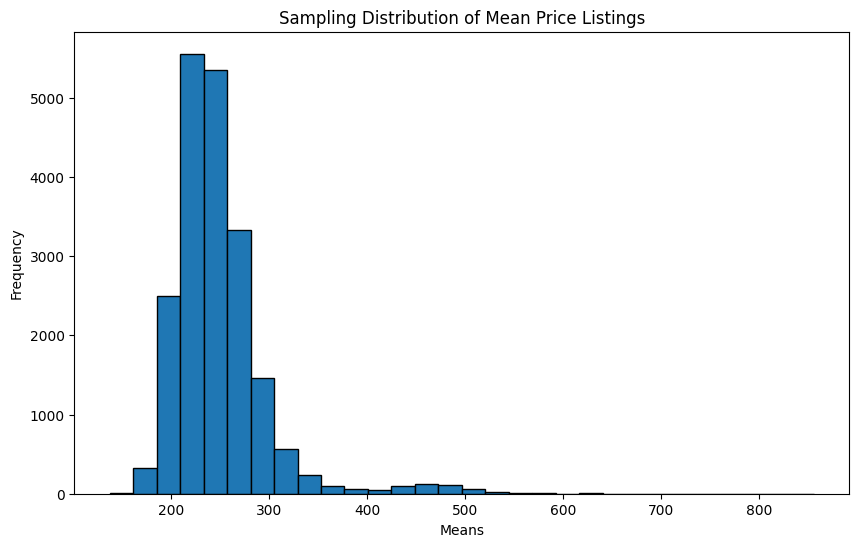

In [31]:
# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(samples_estimates['sample_mean'], bins=30, edgecolor='black')


# Add titles and labels
plt.title('Sampling Distribution of Mean Price Listings')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [32]:
# bootstrapping NOW
np.random.seed(1234)
one_sample = airbnb.sample(n=40)
one_sample

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price
2912,5.970000e+17,Riley Park,Entire home/apt,9,3.0,4.0,5.0,214
787,1.986261e+07,Mount Pleasant,Entire home/apt,9,2.0,3.0,3.0,109
2696,5.333958e+07,Arbutus Ridge,Entire home/apt,3,1.0,1.0,0.0,200
3017,6.310000e+17,West End,Entire home/apt,2,1.0,1.0,0.0,223
1226,2.745958e+07,Downtown,Entire home/apt,1,NaN,1.0,NaN,126
2620,5.255417e+07,Downtown Eastside,Entire home/apt,4,1.0,1.0,2.0,198
4883,9.790000e+17,Downtown Eastside,Entire home/apt,7,2.0,3.0,4.0,834
608,1.554257e+07,Kitsilano,Entire home/apt,5,1.0,2.0,3.0,99
1400,3.124019e+07,Arbutus Ridge,Private room,2,1.0,1.0,2.0,133
149,3.100878e+06,Downtown,Entire home/apt,2,1.0,1.0,0.0,60


In [33]:
one_sample["price"].mean()

np.float64(219.85)

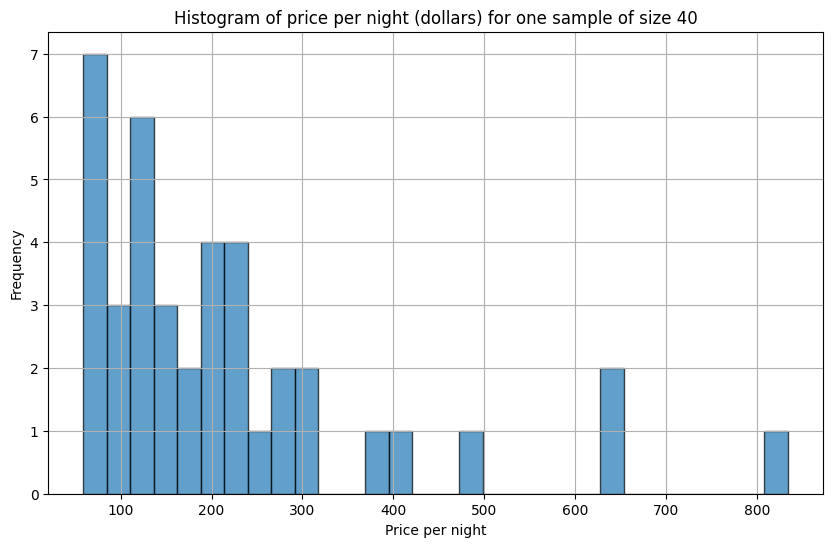

In [34]:
# Histogram of price per night (dollars) for one sample of size 40.
plt.figure(figsize=(10, 6))
plt.hist(one_sample['price'], bins=30, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Histogram of price per night (dollars) for one sample of size 40')
plt.xlabel('Price per night')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [ ]:
boot1 = one_sample.sample(frac = 1, replace= True) # fraction 100%, exact same as the original 

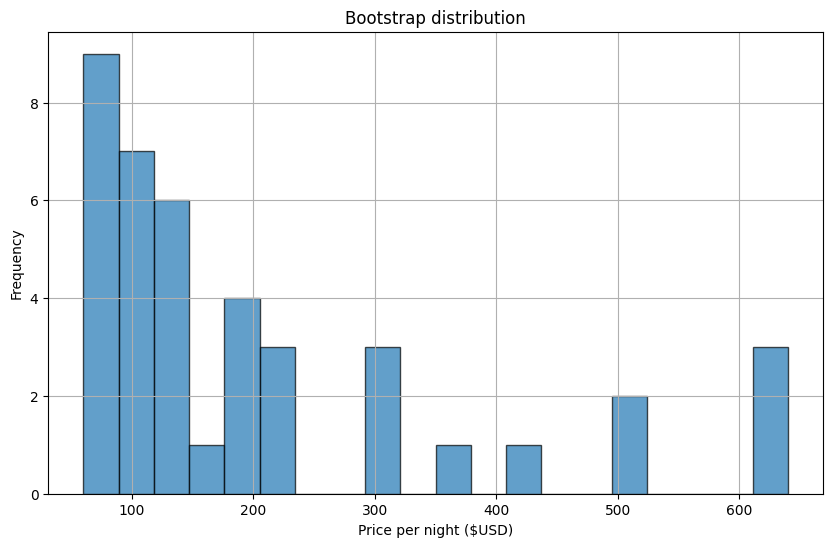

In [36]:
# Create a bootstrap sample from one_sample by sampling 100% of the rows (frac=1) with replacement.
boot1 = one_sample.sample(frac=1, replace=True)
# boot1 is the resulting bootstrap sample, where some rows may appear multiple times, and others may not appear at all.

# Plot the histogram of the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(boot1['price'], bins=20, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Bootstrap distribution')
plt.xlabel('Price per night ($USD)')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [37]:
# boot strap 20
bootstrap_samples = [] #initalize an empty list
for i in range(20_000): 
    sample = one_sample.sample(frac= 1, replace= True)
    sample = sample.assign(replicate = i)
    bootstrap_samples.append(sample)

In [38]:
boot2000 = pd.concat(bootstrap_samples)
boot2000

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price,replicate
3017,6.310000e+17,West End,Entire home/apt,2,1.0,1.0,0.0,223,0
391,9.636681e+06,Downtown Eastside,Entire home/apt,2,NaN,1.0,NaN,80,0
1619,3.519493e+07,West End,Entire home/apt,3,1.0,1.0,2.0,143,0
3851,8.160000e+17,Hastings-Sunrise,Entire home/apt,4,1.0,2.0,2.0,300,0
988,2.348250e+07,Fairview,Entire home/apt,2,1.0,1.0,1.0,118,0
...,...,...,...,...,...,...,...,...,...
2696,5.333958e+07,Arbutus Ridge,Entire home/apt,3,1.0,1.0,0.0,200,19999
2162,4.510529e+07,Kensington-Cedar Cottage,Entire home/apt,4,1.0,2.0,3.0,169,19999
1465,3.287258e+07,Kitsilano,Entire home/apt,4,2.0,2.0,2.0,136,19999
3560,7.510000e+17,Kitsilano,Entire home/apt,4,1.0,1.0,2.0,269,19999


In [41]:
boot_means = boot2000.groupby("replicate")["price"].mean().reset_index(name="mean_price")
boot_means

,replicate,mean_price
0,0,205.800
1,1,183.925
2,2,211.600
3,3,239.475
4,4,245.150
...,...,...
19995,19995,217.450
19996,19996,204.600
19997,19997,216.900
19998,19998,198.375


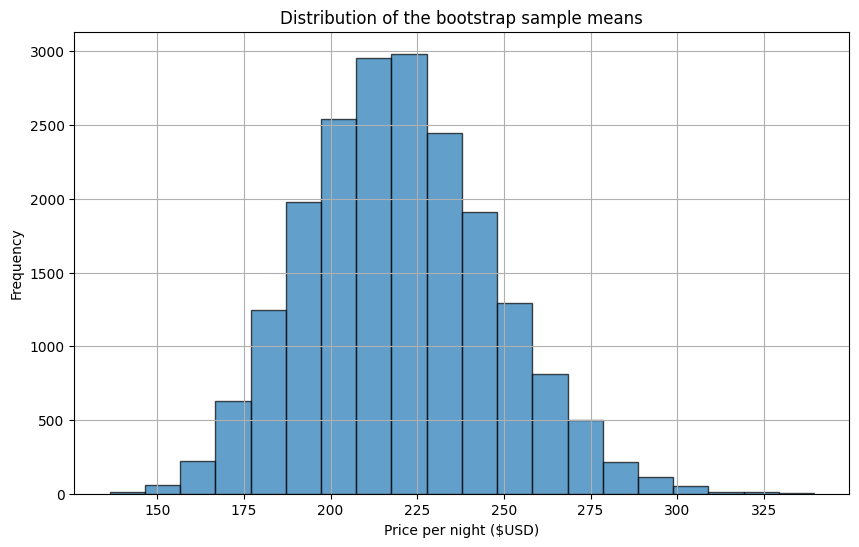

In [42]:
# Plot the histogram of the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(boot_means['mean_price'], bins=20, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Distribution of the bootstrap sample means')
plt.xlabel('Price per night ($USD)')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [43]:
# confidence interval
boot_means["mean_price"].quantile([0.025,0.975])

0.025    171.248750
0.975    276.300625
Name: mean_price, dtype: float64